# 5 · How fast is BAND? A comparison with LAPACK, SuperLU, SUNDIALS and SciPy

This notebook summarizes the benchmark study in [`docs/benchmarks.md`](../docs/benchmarks.md). It **reads the saved results** in `benchmarks/results/` and re-plots them, so it runs in seconds. To regenerate the data, follow the *Reproducing* section of that document.

The comparison has layers, because "which solver is faster?" depends on what is being solved:

1. **Layer 1: one linear block solve.** Pure linear algebra: BAND against banded LAPACK, sparse SuperLU and dense LAPACK, all on the same matrices.
2. **Layer 2: a whole transient simulation**, the coupled binary-electrolyte DAE from [notebook 2](02_binary_electrolyte.ipynb). This adds time stepping, Newton iterations and residual evaluations. BAND with fixed-step BDF2 is compared against the adaptive BDF integrators in SUNDIALS IDA and SciPy.

The machine was an Apple M1 Pro using one core, so the timings are indicative, and the **ratios** carry over to other machines better than the absolute times.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bandsolver as bs

# Plot style: categorical colours in fixed order, an ordinal blue ramp for time series,
# neutral ink for text, thin marks and a recessive grid.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]   # light -> dark
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e0"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": INK2, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "lines.markersize": 6, "legend.frameon": False,
    "figure.dpi": 110, "font.size": 10, "axes.titlesize": 11,
})
print("bandsolver", bs.__version__, "| backends:", bs.BACKENDS)
import csv, json, pathlib
RESULTS = pathlib.Path("..") / "benchmarks" / "results"
env = json.loads((RESULTS / "env.json").read_text())
print(f"benchmarks run on: {env['cpu']} | {env['platform']} | python {env['python']} | "
      + ", ".join(f"{k} {v}" for k, v in env["packages"].items()))

def read(name):
    return list(csv.DictReader((RESULTS / name).open()))

bandsolver 0.1.1 | backends: ('cpp', 'fortran')
benchmarks run on: Apple M1 Pro | macOS-14.6.1-arm64-arm-64bit-Mach-O | python 3.13.3 | bandsolver 0.1.1, numpy 2.5.3, scipy 1.18.1, scikit-sundae 1.1.3, matplotlib 3.11.2


## Layer 1: one block-tridiagonal solve

Every method solves the same random system with $n$ unknowns per node and $n_j$ nodes, including the $\mathsf X,\mathsf Y$ endpoint blocks. For banded LAPACK those two blocks widen the band to $3n-1$ on each side. Only the factor-and-solve step is timed, and every solution's backward error is below $10^{-15}$.

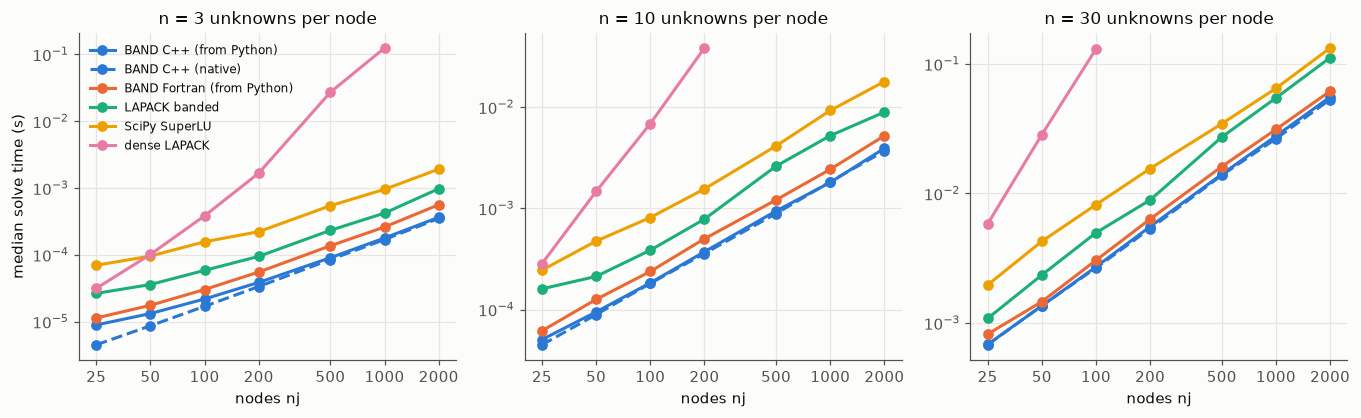

BAND C++ speed-up vs LAPACK banded : min 1.6x, median 2.4x, max 3.9x
BAND C++ speed-up vs SuperLU       : min 2.3x, median 4.6x, max 8.8x
factor storage at n=30, nj=2000: BAND 14.9 MB, LAPACK banded 128.6 MB, SuperLU 65.5 MB


In [2]:
rows = read("linear.csv")
t = {(r["method"], int(r["n"]), int(r["nj"])): float(r["median_s"]) for r in rows}
mem = {(r["method"], int(r["n"]), int(r["nj"])): float(r["factor_bytes"]) for r in rows}
njs = sorted({int(r["nj"]) for r in rows})
series = [("band_cpp_py", "BAND C++ (from Python)", BLUE, "-"), ("band_cpp_native", "BAND C++ (native)", BLUE, "--"),
          ("band_fortran_py", "BAND Fortran (from Python)", ORANGE, "-"), ("lapack_band", "LAPACK banded", AQUA, "-"),
          ("superlu_natural", "SciPy SuperLU", "#eda100", "-"), ("dense_lapack", "dense LAPACK", "#e87ba4", "-")]
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.9))
for ax, n in zip(axes, [3, 10, 30]):
    for m, label, color, ls in series:
        pts = [(nj, t[(m, n, nj)]) for nj in njs if (m, n, nj) in t]
        ax.loglog(*zip(*pts), ls, marker="o", color=color, label=label)
    ax.set_title(f"n = {n} unknowns per node"); ax.set_xlabel("nodes nj")
    ax.set_xticks(njs, [str(j) for j in njs]); ax.minorticks_off()
axes[0].set_ylabel("median solve time (s)"); axes[0].legend(fontsize=8, loc="upper left")
fig.tight_layout(); plt.show()

ratios = lambda other: sorted(t[(other, n, nj)] / t[("band_cpp_py", n, nj)]
                              for n in [1, 3, 5, 10, 20, 30] for nj in njs)
for other, name in [("lapack_band", "LAPACK banded"), ("superlu_natural", "SuperLU")]:
    r = ratios(other)
    print(f"BAND C++ speed-up vs {name:14s}: min {r[0]:.1f}x, median {r[len(r) // 2]:.1f}x, max {r[-1]:.1f}x")
print(f"factor storage at n=30, nj=2000: BAND {mem[('band_cpp_py', 30, 2000)] / 1e6:.1f} MB, "
      f"LAPACK banded {mem[('lapack_band', 30, 2000)] / 1e6:.1f} MB, SuperLU {mem[('superlu_natural', 30, 2000)] / 1e6:.1f} MB")

BAND is the fastest method at every size. Its node-by-node elimination works with dense $n\times n$ blocks and never touches the zeros inside the band. Two further points:

- The **solid and dashed blue lines nearly coincide**. Calling BAND from Python costs only about 5 µs per call, which matters only for the smallest systems.
- The **Fortran core** (orange) is timed with its default `kernel="fast"` column-major loops. It is at parity with the C++ core natively for blocks with $n \ge 5$; through Python it pays for the C ABI's block transposes. Smaller blocks keep a per-node overhead (see `docs/benchmarks.md`).

## Layer 2: a whole transient simulation

Now the question changes to: *how long does it take to integrate the binary-electrolyte DAE to $t=5$ s with a given accuracy?* All stacks solve the same finite-volume discretization, and the error is measured against a very tight reference solution.

| stack | time stepping | per-step solve |
|---|---|---|
| bandsolver | fixed $\Delta t$, backward Euler or BDF2 (user code) | full Newton, or **one linearized correction per step** (the archival usage) |
| `bs.integrate` | fixed $\Delta t$ or adaptive BDF 1–2 (built in) | Newton with a tolerance tied to rtol; one BAND factorization **reused across steps** (switchable) |
| SUNDIALS IDA | adaptive step size and order 1–5 | modified Newton with Jacobian reuse, band LU |
| SciPy BDF | adaptive step size and order 1–5 | the potential eliminated by hand (SciPy has no DAE support) |

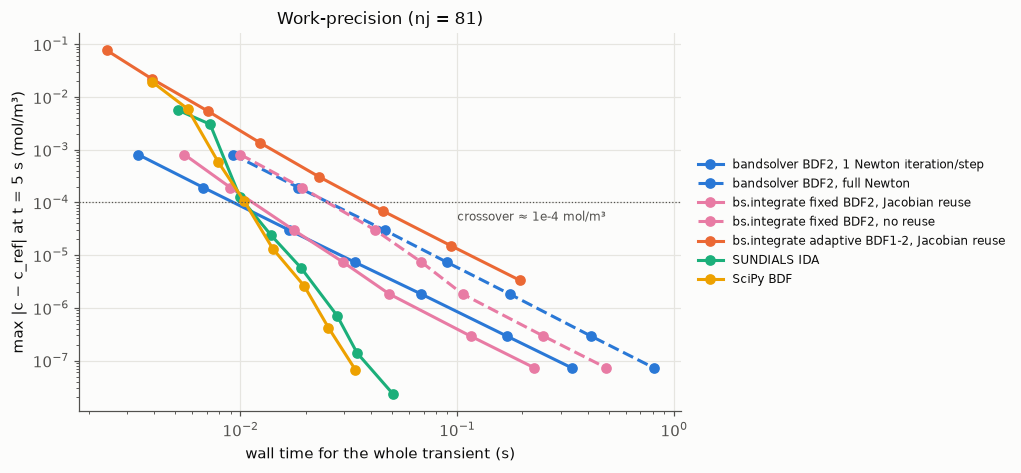

In [3]:
wp = read("transient_wp.csv")
tseries = [("bandsolver BDF2, 1 Newton iter/step", "bandsolver BDF2, 1 Newton iteration/step", BLUE, "-"),
           ("bandsolver BDF2", "bandsolver BDF2, full Newton", BLUE, "--"),
           ("integrate fixed BDF2, reuse", "bs.integrate fixed BDF2, Jacobian reuse", "#e87ba4", "-"),
           ("integrate fixed BDF2, no reuse", "bs.integrate fixed BDF2, no reuse", "#e87ba4", "--"),
           ("integrate adaptive BDF1-2, reuse", "bs.integrate adaptive BDF1-2, Jacobian reuse", ORANGE, "-"),
           ("SUNDIALS IDA", "SUNDIALS IDA", AQUA, "-"), ("SciPy BDF", "SciPy BDF", "#eda100", "-")]
fig, ax = plt.subplots(figsize=(9.4, 4.4))
for m, label, color, ls in tseries:
    pts = sorted((float(r["wall_s"]), float(r["error"])) for r in wp if r["method"] == m)
    ax.loglog(*zip(*pts), ls, marker="o", color=color, label=label)
ax.axhline(1e-4, color=INK2, linewidth=0.8, linestyle=":")
ax.annotate("crossover ≈ 1e-4 mol/m³", xy=(0.1, 7e-5), va="top", color=INK2, fontsize=8)
ax.set_xlabel("wall time for the whole transient (s)"); ax.set_ylabel("max |c − c_ref| at t = 5 s (mol/m³)")
ax.set_title("Work-precision (nj = 81)"); ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
fig.tight_layout(); plt.show()

Read the plot as *lower-left is better*:

- **Above an error of about $10^{-4}$ mol/m³** (roughly $10^{-6}$ relative to $c$), bandsolver's linearized BDF2 is the **fastest** stack. Its steps are the cheapest, and at modest accuracy it needs few of them.
- **Below that**, the adaptive, variable-order BDF integrators win. At fixed step size and second order, BDF2 needs 10–14× more steps than order-5 BDF near $10^{-7}$.
- **Full Newton** (dashed) is 2.7× more expensive than one linearized correction, for *no* accuracy gain on this mildly nonlinear problem. Its default Newton tolerance is far tighter than the step's truncation error.

The per-step costs make this concrete:

In [4]:
mesh = read("transient_mesh.csv")
d = {(r["method"], int(r["nj"])): float(r["per_step_s"]) * 1e6 for r in mesh}
cols = [("bandsolver BDF2, 1 iter (dt=5e-3)", "BAND BDF2, 1 iter"), ("bandsolver BDF2 (dt=5e-3)", "BAND BDF2, Newton"),
        ("integrate fixed BDF2, reuse (dt=5e-3)", "integrate fixed"), ("integrate adaptive, reuse (rtol=1e-6)", "integrate adaptive"),
        ("SUNDIALS IDA (rtol=1e-6)", "IDA"), ("SciPy BDF (rtol=1e-6)", "SciPy BDF")]
print(f"{'nj':>6s} " + " ".join(f"{c[1]:>18s}" for c in cols) + "   (µs per time step)")
for nj in sorted({int(r["nj"]) for r in mesh}):
    print(f"{nj:6d} " + " ".join(f"{d[(c[0], nj)]:18.0f}" for c in cols))

    nj  BAND BDF2, 1 iter  BAND BDF2, Newton    integrate fixed integrate adaptive                IDA          SciPy BDF   (µs per time step)
    41                 63                161                 45                 87                 87                100
    81                 67                174                 50                 94                 99                111
   161                 83                215                 59                112                112                126
   321                102                273                 70                140                138                156
   641                149                396                 99                199                187                218
  1281                232                625                152                311                236                320


In this Python setup, most of bandsolver's per-step time goes into building the residual and Jacobian blocks in numpy. At $n_j = 81$ that is about 51 µs per Newton iteration, against about 10 µs for the BAND solve itself. IDA amortizes its Jacobian over many steps, and so does `bs.integrate` with `jacobian_reuse=True`: with a fixed step it needs only 2–4 Jacobians for the whole run, which gives it the cheapest step in the table.

## Conclusions

1. **As a linear kernel**, BAND is the best option tested for one-dimensional block-banded systems: 1.6–3.9× faster than banded LAPACK and up to 8.8× faster than SuperLU, with up to 9× less memory.
2. **For transient simulations**, fixed-step BDF2 on BAND is the fastest choice at *engineering* accuracy, which is typical of long battery-cycling runs. The built-in `bs.integrate` with Jacobian reuse is up to 3.6× faster than a hand-written full-Newton loop, at identical accuracy.
3. **Adaptive BDF1–2** (`bs.integrate`, `adaptive=True`) costs the same per step as IDA and resolves fast transients. At order ≤ 2, though, it needs many more steps than IDA's order-5 BDF for a tight final-time error. For tight tolerances, use IDA.
4. **Next steps:** a higher integrator order, BAND as the linear solver inside SUNDIALS IDA, native residuals to remove the Python fill cost, and a Fortran port of the integrator.

The full method, fairness notes and limitations are in [`docs/benchmarks.md`](../docs/benchmarks.md).